<a href="https://colab.research.google.com/github/Navzz-afk/6thSem-ML-Lab/blob/main/Lab_3_linear_multiple_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
x = [8, 10, 12]
y = [10, 13, 16]

n = len(x)


mean_x = sum(x) / n
mean_y = sum(y) / n


sum_xy = sum(x[i] * y[i] for i in range(n))
sum_x_squared = sum(x[i] ** 2 for i in range(n))


numerator = sum_xy - n * mean_x * mean_y

denominator = sum_x_squared - n * mean_x ** 2

a1 = numerator / denominator

a0 = mean_y - a1 * mean_x

print("Slope (a1):", a1)
print("Intercept (a0):", a0)

x_new = 20
y_pred = a1 * x_new + a0

print("Predicted price for 20-inch pizza:", y_pred)

Slope (a1): 1.5
Intercept (a0): -2.0
Predicted price for 20-inch pizza: 28.0


In [1]:
import numpy as np
from sklearn.linear_model import LinearRegression

#
X = np.array([8,10,12]).reshape(-1,1)
y = np.array([10,13,16])


model = LinearRegression()
model.fit(X,y)


prediction = model.predict([[20]])

print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)
print("Predicted price for 20 inch:", prediction[0])

Slope: 1.4999999999999998
Intercept: -1.9999999999999982
Predicted price for 20 inch: 28.0


Saving canada_per_capita_income.csv to canada_per_capita_income.csv
   year  per capita income (US$)
0  1970              3399.299037
1  1971              3768.297935
2  1972              4251.175484
3  1973              4804.463248
4  1974              5576.514583
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   year                     47 non-null     int64  
 1   per capita income (US$)  47 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 884.0 bytes
None

Predicted Per Capita Income for 2020:
41288.69409441762


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


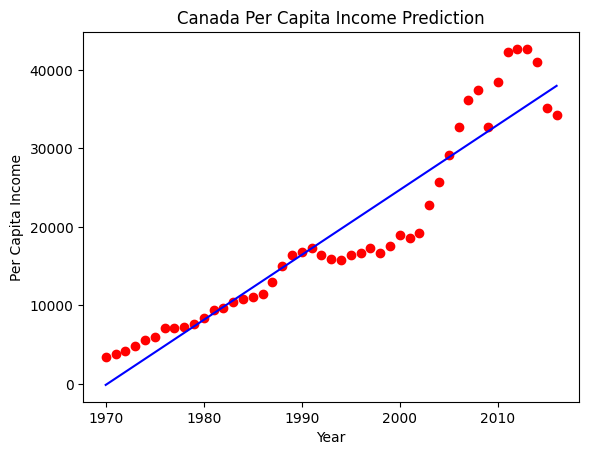

In [6]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Upload file manually in Colab
from google.colab import files
uploaded = files.upload()

# Load dataset
df = pd.read_csv('canada_per_capita_income.csv')

print(df.head())
print(df.info())

# Assuming columns are: 'year' and 'per capita income (US$)'
X = df[['year']]
y = df['per capita income (US$)']

# Create and train model
model = LinearRegression()
model.fit(X, y)

# Predict for year 2020
prediction_2020 = model.predict([[2020]])

print("\nPredicted Per Capita Income for 2020:")
print(prediction_2020[0])

# Plot regression line
plt.scatter(X, y, color='red')
plt.plot(X, model.predict(X), color='blue')
plt.xlabel("Year")
plt.ylabel("Per Capita Income")
plt.title("Canada Per Capita Income Prediction")
plt.show()

Saving salary.csv to salary (1).csv
   YearsExperience  Salary
0              1.1   39343
1              1.3   46205
2              1.5   37731
3              2.0   43525
4              2.2   39891
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  28 non-null     float64
 1   Salary           30 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 612.0 bytes
None

Predicted Salary for 12 Years of Experience:
139049.6749539778


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


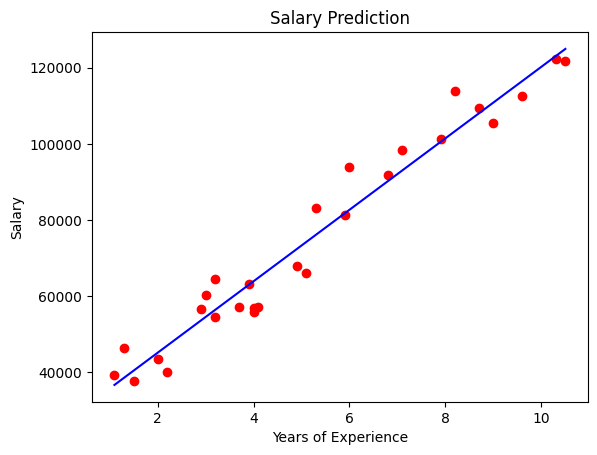

In [9]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Upload file manually in Colab
from google.colab import files
uploaded = files.upload()

# Load dataset
df = pd.read_csv('salary.csv')

print(df.head())
print(df.info())

# Handle missing values by dropping rows with NaNs
df = df.dropna()

# Assuming columns are: 'YearsExperience' and 'Salary'
X = df[['YearsExperience']]
y = df['Salary']

# Create and train model
model = LinearRegression()
model.fit(X, y)

# Predict salary for 12 years experience
salary_12 = model.predict([[12]])

print("\nPredicted Salary for 12 Years of Experience:")
print(salary_12[0])

# Plot regression line
plt.scatter(X, y, color='red')
plt.plot(X, model.predict(X), color='blue')
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Salary Prediction")
plt.show()

In [10]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

# Upload file
from google.colab import files
uploaded = files.upload()

# Load dataset
df = pd.read_csv('hiring.csv')

print(df.head())
print(df.info())

# -----------------------------
# Data Preprocessing
# -----------------------------

# Fill missing experience with 0
df['experience'] = df['experience'].fillna(0)

# Convert textual numbers to numeric if necessary
df['experience'] = df['experience'].replace({
    'zero': 0,
    'one': 1,
    'two': 2,
    'three': 3,
    'four': 4,
    'five': 5,
    'six': 6,
    'seven': 7,
    'eight': 8,
    'nine': 9,
    'ten': 10,
    'eleven': 11,
    'twelve': 12
})

df['experience'] = df['experience'].astype(float)

# Fill missing test scores with median
df['test_score(out of 10)'] = df['test_score(out of 10)'].fillna(df['test_score(out of 10)'].median())

# Define features and target
X = df[['experience', 'test_score(out of 10)', 'interview_score(out of 10)']]
y = df['salary($)']

# Train model
model = LinearRegression()
model.fit(X, y)

# -----------------------------
# Predictions
# -----------------------------

pred1 = model.predict([[2, 9, 6]])
pred2 = model.predict([[12, 10, 10]])

print("\nPredicted salary for (2 yr exp, 9 test, 6 interview):", pred1[0])
print("Predicted salary for (12 yr exp, 10 test, 10 interview):", pred2[0])

Saving hiring.csv to hiring.csv
  experience  test_score(out of 10)  interview_score(out of 10)  salary($)
0        NaN                    8.0                           9      50000
1        NaN                    8.0                           6      45000
2       five                    6.0                           7      60000
3        two                   10.0                          10      65000
4      seven                    9.0                           6      70000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 4 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   experience                  6 non-null      object 
 1   test_score(out of 10)       7 non-null      float64
 2   interview_score(out of 10)  8 non-null      int64  
 3   salary($)                   8 non-null      int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 388.0+ bytes
None

Pre

/tmp/ipython-input-988727332.py:24: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['experience'] = df['experience'].replace({
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [14]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Upload file
from google.colab import files
uploaded = files.upload()

# Load dataset
df = pd.read_csv('1000_Companies.csv')

print(df.head())
print(df.info())

# -----------------------------
# Data Preprocessing
# -----------------------------

# Separate features and target
X = df[['R&D Spend', 'Administration', 'Marketing Spend', 'State']]
y = df['Profit']

# One Hot Encoding for State column
ct = ColumnTransformer(
    transformers=[
        ('encoder', OneHotEncoder(drop='first'), ['State'])
    ],
    remainder='passthrough'
)

X = ct.fit_transform(X)

# Train model
model = LinearRegression()
model.fit(X, y)

# -----------------------------
# Prediction
# -----------------------------

# Order must match transformed structure
# Since drop='first', one state column is removed to avoid dummy variable trap

new_data = pd.DataFrame({
    'R&D Spend': [91694.48],
    'Administration': [515841.3],
    'Marketing Spend': [11931.24],
    'State': ['Florida']
})

new_data_transformed = ct.transform(new_data)

profit_prediction = model.predict(new_data_transformed)

print("\nPredicted Profit:", profit_prediction[0])

Saving 1000_Companies.csv to 1000_Companies (3).csv
   R&D Spend  Administration  Marketing Spend       State     Profit
0  165349.20       136897.80        471784.10    New York  192261.83
1  162597.70       151377.59        443898.53  California  191792.06
2  153441.51       101145.55        407934.54     Florida  191050.39
3  144372.41       118671.85        383199.62    New York  182901.99
4  142107.34        91391.77        366168.42     Florida  166187.94
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        1000 non-null   float64
 1   Administration   1000 non-null   float64
 2   Marketing Spend  1000 non-null   float64
 3   State            1000 non-null   object 
 4   Profit           1000 non-null   float64
dtypes: float64(4), object(1)
memory usage: 39.2+ KB
None

Predicted Profit: 510570.9926108249
